# Spatial Domain Filtering

This notebook demonstrates **smoothing** and **sharpening** filtering in the spatial domain using:
- **Box Filter** (averaging filter)
- **Gaussian Filter** (weighted averaging)
- **Sharpening Filter** (Laplacian-based)

The input image is `BMW.jpeg` from the workspace.

## 1. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Image and Define Helper

In [2]:
image_bgr = cv2.imread('BMW.jpeg')

if image_bgr is None:
    print('Error: Could not load the image. Please check the file path.')
else:
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    print(f'Image loaded successfully. Shape: {image_rgb.shape}')

def display_images(images, titles, cols=3, figsize=(18, 6)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Image loaded successfully. Shape: (720, 720, 3)


## 3. Box Filter (Smoothing / Averaging)

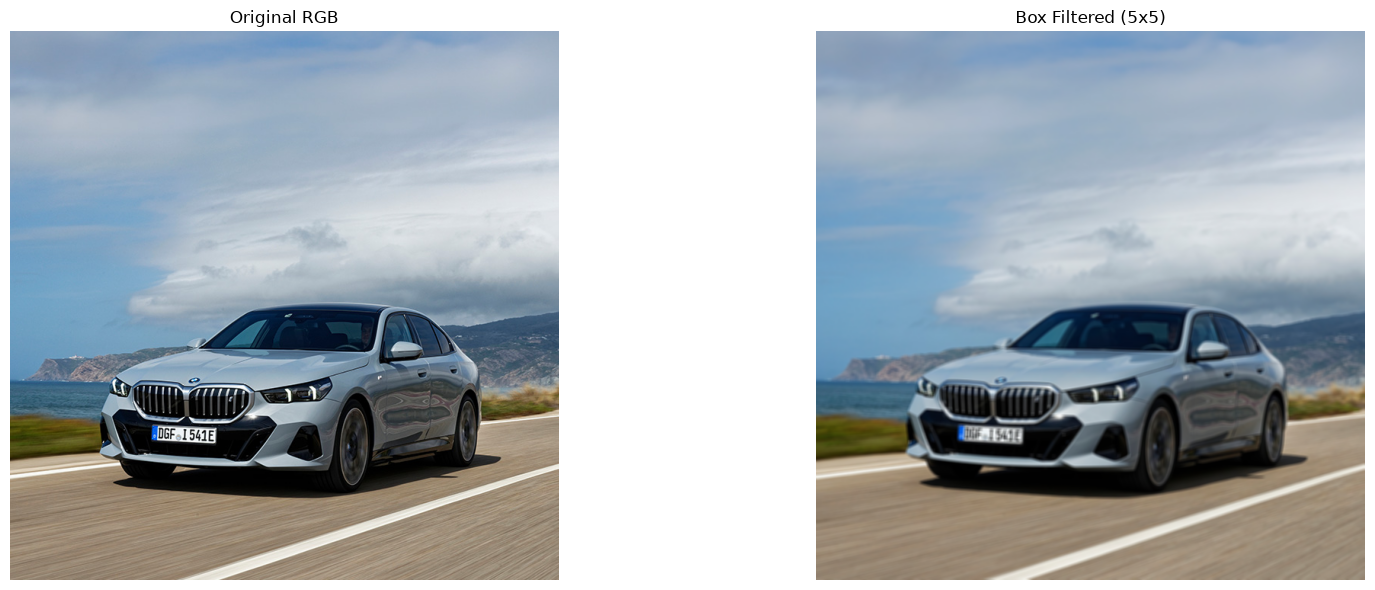

In [3]:
box_filtered = cv2.blur(image_rgb, (5, 5))

display_images(
    [image_rgb, box_filtered],
    ['Original RGB', 'Box Filtered (5x5)'],
    cols=2
)

## 4. Gaussian Filter (Smoothing)

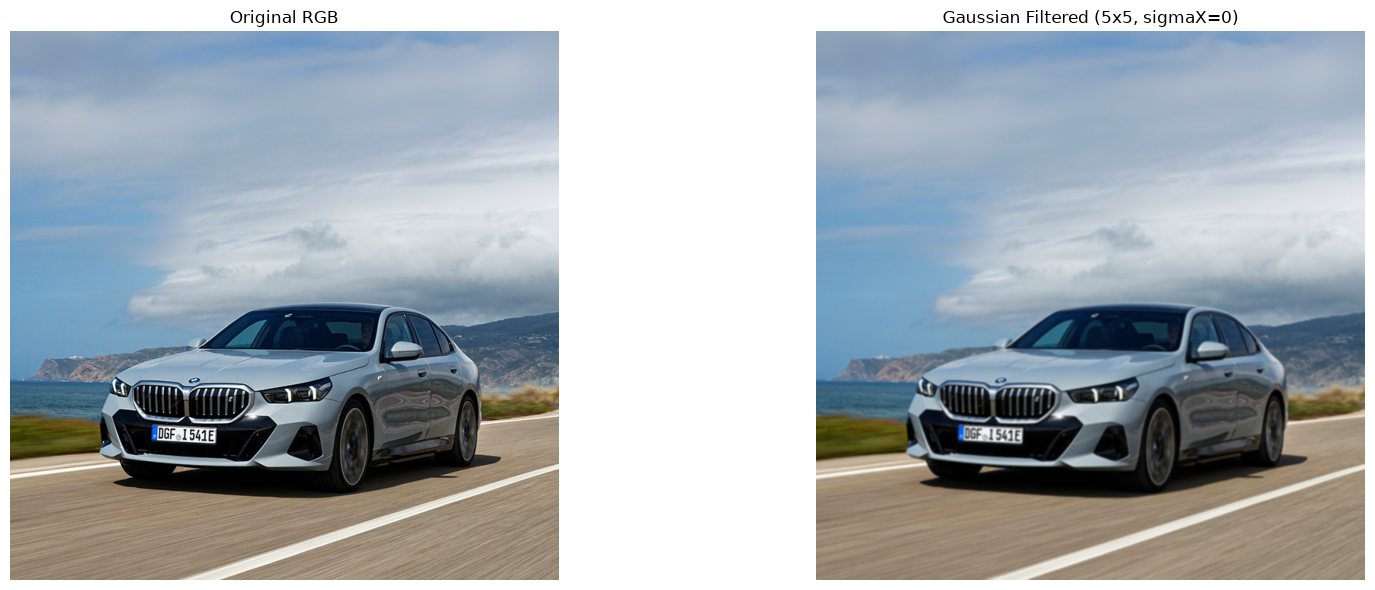

In [4]:
gaussian_filtered = cv2.GaussianBlur(image_rgb, (5, 5), sigmaX=0)

display_images(
    [image_rgb, gaussian_filtered],
    ['Original RGB', 'Gaussian Filtered (5x5, sigmaX=0)'],
    cols=2
)

## 5. Sharpening Filter (Laplacian)

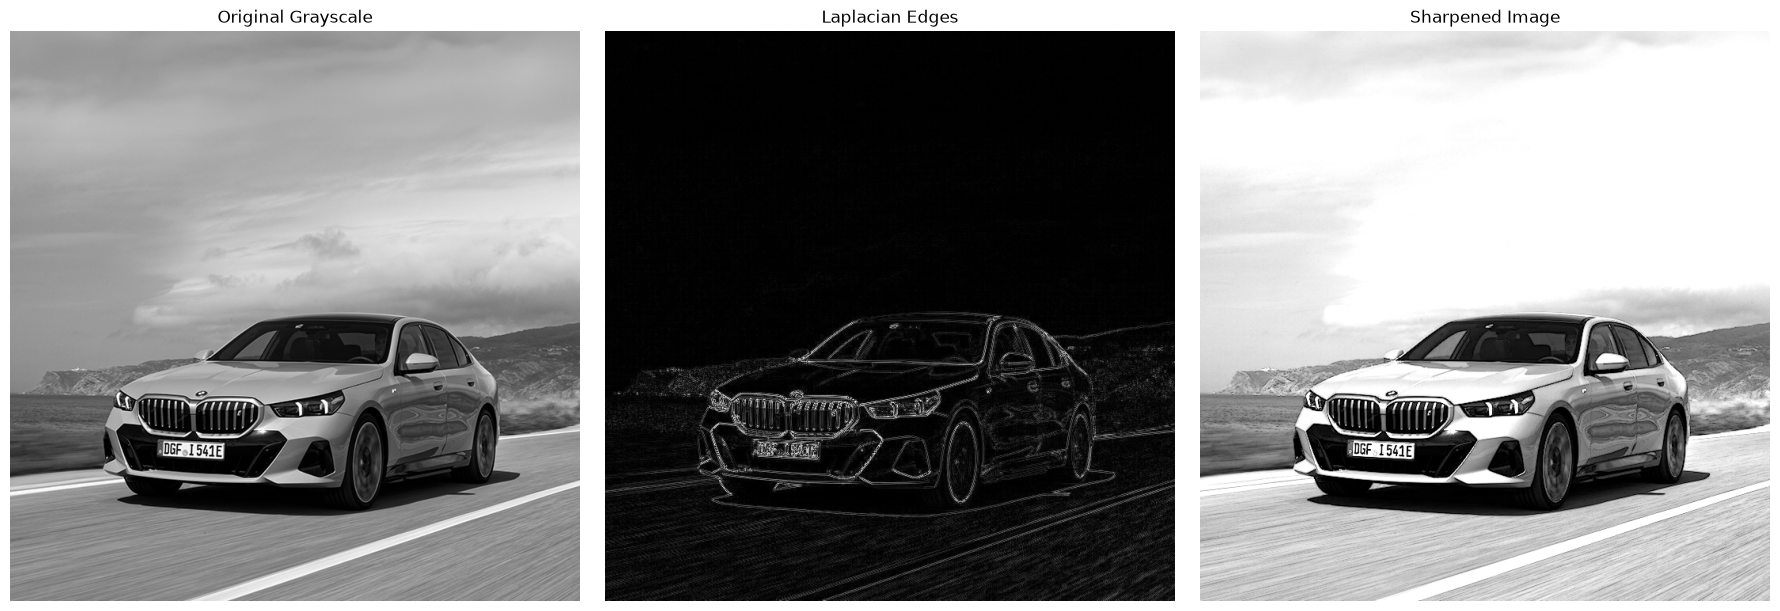

In [5]:
laplacian = cv2.Laplacian(image_gray, cv2.CV_64F)
laplacian_uint8 = np.uint8(np.absolute(laplacian))

sharpened = cv2.addWeighted(image_gray, 1.5, laplacian_uint8, -0.5, 0)

display_images(
    [image_gray, laplacian_uint8, sharpened],
    ['Original Grayscale', 'Laplacian Edges', 'Sharpened Image'],
    cols=3
)

## 6. Combined Comparison: All Filters

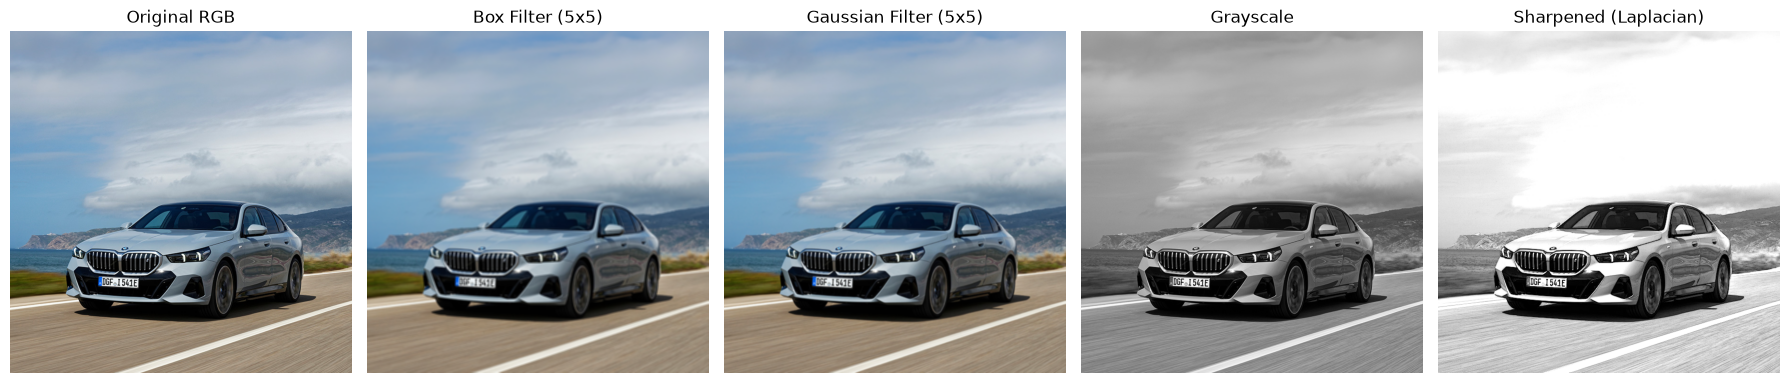

In [6]:
display_images(
    [image_rgb, box_filtered, gaussian_filtered, image_gray, sharpened],
    ['Original RGB', 'Box Filter (5x5)', 'Gaussian Filter (5x5)', 'Grayscale', 'Sharpened (Laplacian)'],
    cols=5
)

## 7. Filter Kernels Visualization

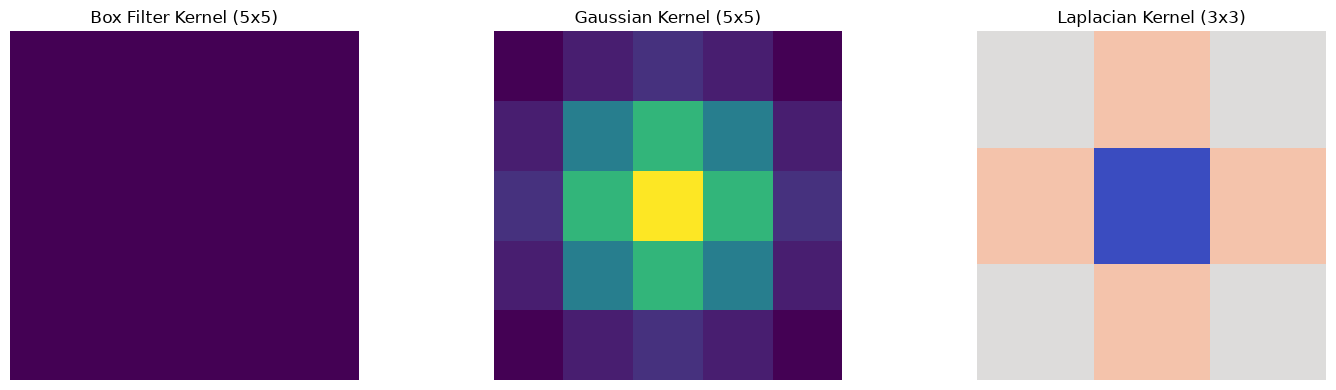

In [7]:
box_kernel = np.ones((5, 5), np.float32) / 25
gaussian_kernel = cv2.getGaussianKernel(5, sigma=0) @ cv2.getGaussianKernel(5, sigma=0).T
laplacian_kernel = np.array([[0, 1, 0],
                              [1, -4, 1],
                              [0, 1, 0]], dtype=np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(box_kernel, cmap='viridis')
axes[0].set_title('Box Filter Kernel (5x5)')
axes[0].axis('off')

axes[1].imshow(gaussian_kernel, cmap='viridis')
axes[1].set_title('Gaussian Kernel (5x5)')
axes[1].axis('off')

axes[2].imshow(laplacian_kernel, cmap='coolwarm', vmin=-4, vmax=4)
axes[2].set_title('Laplacian Kernel (3x3)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 8. Explanation of Filters

### Box Filter (Averaging Filter)
- Replaces each pixel with the **average** of all pixels under the kernel window.
- Every pixel in the kernel window has **equal weight**.
- Effective for **noise reduction** but blurs edges along with noise.
- Kernel: all elements are `1/(kernel_size)`.

### Gaussian Filter
- A weighted averaging filter where weights follow a **Gaussian distribution**.
- Pixels closer to the center receive **higher weights**; distant pixels receive lower weights.
- Produces **smoother blurring** than the box filter and preserves edges better.
- Controlled by `sigmaX` (standard deviation in X direction).

### Sharpening Filter (Laplacian)
- The Laplacian is a **second-order derivative** operator that detects regions of rapid intensity change.
- It highlights **edges** and fine details.
- Sharpening is achieved by **adding** the Laplacian back to the original image: `sharpened = original + alpha * laplacian`.
- A negative Laplacian coefficient in `addWeighted` subtracts the edges, enhancing contrast at boundaries.